In [22]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
from datetime import datetime, timezone
from tavily import TavilyClient
from pydantic import BaseModel
from typing import Optional

class StockNewsItem(BaseModel):
    id: int
    ticker: str
    company_name: str
    title: str
    content: str
    raw_content: str
    url: str
    published_date: Optional[datetime] = None


tavily_client = TavilyClient();

# Domain preset
DOMAIN_PRESETS = {
    "general": [
        "reuters.com",
        "cnbc.com",
        "finance.yahoo.com",
        "marketwatch.com",
        "bloomberg.com",
    ],
    "deep_analysis": [
        "seekingalpha.com",
        "barrons.com",
        "wsj.com",
        "morningstar.com",
        "ft.com",
    ],
    "realtime": [
        "cnbc.com",
        "benzinga.com",
        "finance.yahoo.com",
        "marketwatch.com",
        "thestreet.com",
    ],
    "mix_and_match":[
        "bloomberg.com",
        "reuters.com",
        "wsj.com",
        "ft.com",
        "cnbc.com",
        "finance.yahoo.com"
    ]
}


def parse_published_date(date_str: Optional[str]) -> Optional[datetime]:
    """Convert string datatime to datetime"""
    if not date_str:
        return None
    
    formats = [
        "%Y-%m-%dT%H:%M:%SZ",       # 2025-01-15T10:30:00Z
        "%Y-%m-%dT%H:%M:%S%z",      # 2025-01-15T10:30:00+00:00
        "%Y-%m-%d %H:%M:%S",        # 2025-01-15 10:30:00
        "%Y-%m-%d",                 # 2025-01-15
        "%a, %d %b %Y %H:%M:%S %z", # Mon, 15 Jan 2025 10:30:00 +0000
        "%a, %d %b %Y %H:%M:%S %Z"  # Tue, 02 Jun 2026 20:07:00 GMT
    ]

    for fmt in formats:
        try:
            dt = datetime.strptime(date_str, fmt)
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=timezone.utc)
            return dt
        except ValueError:
            continue
    
    #None of format is succeded
    return None


def search_stock_news(ticker: str, company_name: str, max_results: int) -> list[StockNewsItem]:
    """return the most recent news limited by number"""
    
    domains = DOMAIN_PRESETS["deep_analysis"]
    query = f'{company_name} ({ticker}) latest stock news'

    response = tavily_client.search(query=query, 
                                    topic="news", 
                                    max_results=max_results,
                                    search_depth="basic",
                                    include_raw_content="markdown",
                                    days = 3,
                                    include_domains=domains)
    
    results = [StockNewsItem(
        id = idx,
        ticker=ticker,
        company_name=company_name,
        title=r['title'],
        content=r['content'],
        raw_content=r['raw_content'],
        url=r['url'],
        published_date=parse_published_date(r['published_date'])
    ) for idx, r in enumerate(response['results'])]
   
    return results



In [24]:
from langgraph.graph.message import add_messages
from datetime import datetime

class NewsItems(BaseModel):
    id: int
    title: str
    content: str    
    raw_content: str
    summary: str
    summary_kr: str
    published_date: Optional[datetime]
    url: str
    sentiment_label: str
    sentiment_score: float


def merge_news_items(existing: list[NewsItems], new: list) -> list[NewsItems]:
    """Merge new news items into existing list, updating fields if item id already exists."""
    existing_map = {item.id: item for item in existing}
    
    for new_item in new:
        new_dict = new_item.model_dump()

        if new_dict.get('id') in existing_map:            
            existing_map[new_dict['id']] = existing_map[new_dict['id']].model_copy(
                update={k: v for k, v in new_dict.items() if v is not None}
            )
        else:
            existing_map[new_dict['id']] = NewsItems(**new_dict)
    
    return list(existing_map.values())

In [25]:
#define GraphState
from typing import Optional, Annotated
from pydantic import BaseModel, Field

class StockNewsState(BaseModel):
    ticker: str = Field(description="Ticker symbol. e.g. SNDK, APPL")
    company_name: Optional[str] = Field(default=None, description="The company name from the ticker symbol. e.g. Apple, inc.")
    news_items: Annotated[Optional[list[NewsItems]], merge_news_items] = Field(default_factory=list)

In [26]:
from app.utils.financial import get_company_name

def load_news(state: StockNewsState):
    """Load news from data base if news exist; fill the state"""
    return {}

def route_messages(state: StockNewsState):
    """if there are news items in the state go to END; otherwise, go grab news!"""
    if(state.news_items):
        return 'end'
    return 'search_news'


def search_news(state: StockNewsState):
    """Search Top 3 news"""
    company_name = get_company_name(state.ticker)
    stock_news = search_stock_news(state.ticker, company_name, 3)

    news_items = [NewsItems(
            id=idx,
            title=n.title,
            content=n.content,
            content_kr='',
            raw_content=n.raw_content,
            summary='',
            summary_kr='',
            published_date=n.published_date,
            url=n.url,
            sentiment_label='',
            sentiment_score=0.0
            ) for idx, n in enumerate(stock_news)]                  
    
    return {"company_name": company_name, "news_items":news_items}


def save_to_db(state: StockNewsState):
    """Save the data to supadb"""
    print(state)
    return {}

In [27]:
from langchain_core.prompts import ChatPromptTemplate
from app.utils.llm_models import get_ollama_llm
from pydantic import BaseModel, Field
from typing import List, Literal

# Model output schema
class NewAnalysis(BaseModel):
    id: int = Field(description="the article id")
    title: str = Field(description="A title of the article")
    summary: str = Field(description="A concise summary of the article in 2-3 sentences (English)")
    summary_kr: str = Field(description="Korean translation of the summary")    
    sentiment_label: Literal["Positive", "Negative", "Neutral"] = Field(description="Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'")
    sentiment_score: float = Field(description="Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)")

class NewsAnalysisList(BaseModel):
    articles: List[NewAnalysis]


def summarize_news(state: StockNewsState):
    """Summarize 3 news and add sentiment and embedding"""


    news_content = "\n\n".join([f"Article {n.id}: \nTitle: {n.title}\nContent: {n.raw_content}\nURL:{n.url}\nDate: {n.published_date}"
                                for n in state.news_items
                                ]).replace("{","{{").replace("}","}}")  
    
    prompt = f"""
    You are a financial news analyst. Analyze the following news articles about {state.ticker} ({state.company_name})

    For each article, provide:

    1. **id**: the article id
    2. **title**: A title of the article
    3. **summary**: A concise summary of the article in 4-5 sentences (English)
    4. **summary_kr**: Korean translation of the summary    
    5. **sentiment_label**: Sentiment analysis result - must of one of: 'Positive', 'Negative', 'Neutral'
    6. **sentiment_score**: Sentiment confidence score between -1.0 (most negative) and 1.0 (most positive)

    News Articles:
    {news_content}   

    Return a JSON object with an "articles" key containing the list of results.
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "You are a financial news analyst specializing in stock market analysis."),
        ("user", prompt)
    ])

      
    llm = get_ollama_llm()
    llm_with_structure = llm.with_structured_output(NewsAnalysisList)

    chain = prompt_template | llm_with_structure

    response = chain.invoke({
        "ticker": state.ticker,
        "company_name": state.company_name,
        "news_content": news_content
    })
   
    return {"news_items": response.articles}


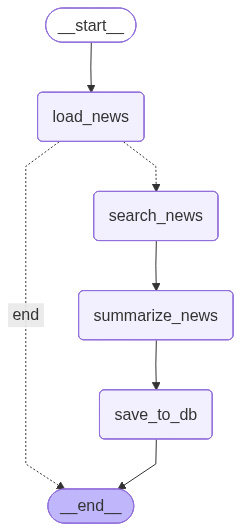

In [28]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder = StateGraph(StockNewsState)
builder.add_node("load_news", load_news)
#builder.add_node("route_messages", route_messages)
builder.add_node("search_news", search_news)
builder.add_node("summarize_news", summarize_news)
builder.add_node("save_to_db", save_to_db)

builder.add_edge(START, "load_news")
#builder.add_edge("load_news","route_messages")
#builder.add_conditional_edges("route_messages", route_messages, {"search_news": "search_news", "end": END})
builder.add_conditional_edges("load_news",route_messages,{"search_news": "search_news", "end":END})
builder.add_edge("search_news","summarize_news")
builder.add_edge("summarize_news", "save_to_db")
builder.add_edge("save_to_db", END)

stock_news_graph = builder.compile()

display(Image(stock_news_graph.get_graph(xray=1).draw_mermaid_png()))


In [29]:
result= stock_news_graph.invoke({"ticker": "SNDK", "company_name": ""})

ticker='SNDK' company_name='Sandisk Corporation' news_items=[NewsItems(id=0, title="AI Stock Frenzy and Marvell's Surge", content="This copy is for your personal, non-commercial use only. Distribution and use of this material are governed by our Subscriber Agreement and by copyright law. # FOMO Is Fueling the AI Stock Frenzy. Marvell Is Just the Latest Sign. Marvell Technology stock surged 30% in a day. ### Chart of the Day: Bitcoin Is Flashing Warning Signs. ### Chart Of The Day: Brent Oil May Be Poised For A Major Rebound. ### The Winning Stocks of the AI Frenzy: Q&A Video and Transcript. # Marvell Stock Just Had Its Best Day Ever. Marvell Technology's stock price has more than tripled in the past 12 months. -0.69% CEO Jensen Huang, who reckons the chips-and-networking company can achieve a market value of more than $1 trillion. # Broadcom Stock Closes at a Record. It’s Getting a Double Boost From Google and Marvell. +4.70% closed at a record on Tuesday after news from two of the big

In [30]:
import pytz
from datetime import datetime, timezone

def to_pst(date_to_convert:Optional[datetime]) -> str:
    if not date_to_convert:
        return None
        
    PST = pytz.timezone("America/Los_Angeles")
    return date_to_convert.astimezone(PST).strftime("%a, %d %b %Y %H:%M:%S %Z")


from IPython.display import Markdown, display

def render_stock_news(state: StockNewsState):
    md = f"# 📈 {state['ticker']} - {state['company_name']} News\n\n"
    
    for i, item in enumerate(state['news_items'], 1):
        
        emoji = {"Positive": "🟢", "Negative": "🔴", "Neutral": "🟡"}.get(item.sentiment_label, "⚪")
        
        md += f"## {i}. {item.title}\n\n"
        md += f"**Published date**: {to_pst(item.published_date)}  \n"
        md += f"**Sentiment**: {emoji} {item.sentiment_label} (score: {item.sentiment_score:.2f})  \n"
        md += f"**URL**: [{item.url}]({item.url})\n\n"
        md += f"### Summary\n{item.summary}\n\n"
        md += f"### Summary in Korean\n{item.summary_kr}\n\n"        
        md += f"### content\n{item.content.replace('#','\#')}\n\n"
        md += "-------------------------------------------------------------\n\n"
    
    display(Markdown(md))

<>:27: SyntaxWarning: invalid escape sequence '\#'
<>:27: SyntaxWarning: invalid escape sequence '\#'
C:\Users\bbind\AppData\Local\Temp\ipykernel_2272\1317864889.py:27: SyntaxWarning: invalid escape sequence '\#'
  md += f"### content\n{item.content.replace('#','\#')}\n\n"


In [31]:
render_stock_news(result)

# 📈 SNDK - Sandisk Corporation News

## 1. AI Stock Frenzy and Marvell's Surge

**Published date**: Tue, 02 Jun 2026 13:07:00 PDT  
**Sentiment**: 🟢 Positive (score: 0.85)  
**URL**: [https://www.barrons.com/articles/ai-marvell-nvidia-stock-market-price-d9c05b51](https://www.barrons.com/articles/ai-marvell-nvidia-stock-market-price-d9c05b51)

### Summary
The article discusses a surge in AI-related stocks driven by investor fear of missing out (FOMO), highlighting Marvell Technology as a key beneficiary. Nvidia CEO Jensen Huang endorsed Marvell, predicting it could join the $1 trillion market cap club soon. Consequently, Marvell's stock price surged significantly, reflecting strong confidence from major industry leaders like Google and Broadcom. The broader tech sector is experiencing record highs fueled by this AI enthusiasm.

### Summary in Korean
이 기사는 FOMO(놓칠까 봐 두려운 심리) 가 AI 관련 주식 시장을 주도하고 있으며, Marvell Technology가 주요 수혜 기업임을 강조합니다. 엔비디아 CEO 젠슨 황은 마벨을 1조 달러 시장 가치 클럽에 진입할 잠재력이 있는 회사로 평가했습니다. 이에 따라 마벨 주가는 급등했으며, 구글과 브로드컴 등 대형 기술 기업의 지지를 받았습니다. 전반적인 기술 섹터는 이러한 AI 열기에 힘입어 기록적인 상승세를 보이고 있습니다.

### content
This copy is for your personal, non-commercial use only. Distribution and use of this material are governed by our Subscriber Agreement and by copyright law. \# FOMO Is Fueling the AI Stock Frenzy. Marvell Is Just the Latest Sign. Marvell Technology stock surged 30% in a day. \#\#\# Chart of the Day: Bitcoin Is Flashing Warning Signs. \#\#\# Chart Of The Day: Brent Oil May Be Poised For A Major Rebound. \#\#\# The Winning Stocks of the AI Frenzy: Q&A Video and Transcript. \# Marvell Stock Just Had Its Best Day Ever. Marvell Technology's stock price has more than tripled in the past 12 months. -0.69% CEO Jensen Huang, who reckons the chips-and-networking company can achieve a market value of more than $1 trillion. \# Broadcom Stock Closes at a Record. It’s Getting a Double Boost From Google and Marvell. +4.70% closed at a record on Tuesday after news from two of the biggest names in tech gave its shares a boost.

-------------------------------------------------------------

## 2. Wise Stock Plunges on Money-Laundering Probe

**Published date**: Mon, 01 Jun 2026 08:11:08 PDT  
**Sentiment**: 🔴 Negative (score: -0.75)  
**URL**: [https://www.wsj.com/livecoverage/stock-market-today-dow-sp-500-nasdaq-06-01-2026/card/wise-stock-plunges-on-money-laundering-probe-hHGK0UTaPoCUPQiU1f6f](https://www.wsj.com/livecoverage/stock-market-today-dow-sp-500-nasdaq-06-01-2026/card/wise-stock-plunges-on-money-laundering-probe-hHGK0UTaPoCUPQiU1f6f)

### Summary
Shares of payment processor Wise dropped more than 10% after news emerged that the company is under investigation in Belgium for potential money-laundering offenses. The Belgian Public Prosecutor's Office stated it has been investigating suspicious transactions totaling roughly $583 million since 2025. This probe focuses on whether Wise Europe’s services were utilized by international criminal organizations, and it is nearing completion.

### Summary in Korean
결제 처리 업체인 와이스의 주가는 벨기에에서 자금 세탁 혐의를 조사받고 있다는 소식에 10% 이상 급락했습니다. 벨기예 공안청은 2025 년부터 약 5억 8천만 달러 규모의 의심 거래를 조사해 왔다고 밝혔습니다. 이 조사는 와이스 유럽이 국제 범죄 조직의 서비스를 이용했는지 여부를 중점적으로 다루고 있으며, 곧 완료될 예정입니다.

### content
\# Wise Stock Plunges on Money-Laundering Probe. Nikkei 66388.08 -0.82%. Hang Seng 25395.07 -0.01%. Shanghai 4057.74 -0.27%. BSE Sensex 74267.34 -0.68%. Singapore 5061.80 0.48%. Kospi 8684.83 -1.18%. ASX-200 8669.20 -0.69%. *   English Edition  Edition Use Alt + Down Arrow to expand. Markets CoverageThe latest news & analysis. Stock Market Today: Nvidia Fuels AI Enthusiasm; Oil Rises. 1, 2026 at 6:27pm ET. Image 1: Joe Stonor hedcut. Image 2: Wise Stock Plunges on Money-Laundering Probe. Shares in payment processor Wise are down more than 10% on news that it is being investigated in Belgium for potential money-laundering offences. The Brussels Public Prosecutor's Office said today that it has been investigating the company's European entity since 2025 over suspicious transactions totaling the equivalent of roughly $583 million. The probe, which focuses on whether Wise Europe’s services were used by international criminal organizations, is at an advanced stage and nearing completion, a spokesperson for the prosecutor’s office said. Image 3Image 4Image 5Image 6Image 7Image 8.

-------------------------------------------------------------

## 3. U.S. Stock Futures Rise Amid Geopolitical Tensions

**Published date**: Mon, 01 Jun 2026 01:33:00 PDT  
**Sentiment**: 🟡 Neutral (score: 0.15)  
**URL**: [https://www.wsj.com/finance/stocks/u-s-stock-futures-rise-even-as-oil-jumps-on-fresh-u-s-iran-hostilities-bbc59517](https://www.wsj.com/finance/stocks/u-s-stock-futures-rise-even-as-oil-jumps-on-fresh-u-s-iran-hostilities-bbc59517)

### Summary
U.S. stock futures rose despite a spike in oil prices caused by fresh hostilities between the U.S. and Iran over drone incidents. The conflict has complicated diplomatic efforts to open the Strait of Hormuz, leading to higher crude oil costs for markets globally. However, investors remain optimistic about equity market performance even as geopolitical risks escalate.

### Summary in Korean
미국과 이란 간의 드론 충돌로 인한 새로운 군사적 긴장으로 인해 유가 상승에도 불구하고 미국 주식 선물 지수는 올랐습니다. 분쟁은 호르무즈 해협 개방을 위한 외교 노력을 복잡하게 만들어 전 세계 시장에서 원유 비용을 높였습니다. 그럼에도 불구하고 투자자들은 지정학적 리스크가 고조되더라도 주주 시장 성과에 대해 낙관적입니다.

### content
\# U.S. Stock Futures Rise Even as Oil Jumps on Fresh U.S.-Iran Hostilities - WSJ. CAC 40 8184.16 0.01%. https://www.wsj.com/finance/stocks/u-s-stock-futures-rise-even-as-oil-jumps-on-fresh-u-s-iran-hostilities-bbc59517. \# U.S. Stock Futures Rise Even as Oil Jumps on Fresh U.S.-Iran Hostilities. The U.S. said it struck Iranian air-defense sites in response to Tehran downing an American drone. U.S. stock futures point to an extension of May’s record-setting rally, even as oil prices rose after the U.S. and Iran exchanged a fresh round of strikes. Brent crude oil prices rose 3% after the U.S. said it struck Iranian air-defense sites in response to Tehran’s downing of an American drone. Meanwhile, Israel expanded its invasion of Lebanon, further complicating efforts to agree on a memorandum of understanding between the U.S. and Iran that would remove blockages in the crucial Strait of Hormuz. \#\#\# Most Popular News. \#\#\#\# Nobody Can Agree How to Keep the Sharks Out of South Africa’s New Club Med. Image 5: Graham Platner’s Wife Flagged Sexually Explicit Texts to His Senate Campaign.

-------------------------------------------------------------

